# **03. Data Cleaning**

## **03.1. Manejo de los valores perdidos o nulos**

### **03.1.1. Echar un vistazo a los datos**

- `pd.read_csv()`: permite leer el archivo csv.
- `np.random.seed()`: establece una semilla para poder reproducir la aleatoriedad.

In [ ]:
import pandas as pd
import numpy as np

nfl_data = pd.read_csv("./archivosDeDatos/NFL Play by Play 2009-2017 (v4).csv", on_bad_lines="skip")

np.random.seed(0)

/tmp/ipykernel_4379/603597355.py:4: DtypeWarning: Columns (25,51,59,60) have mixed types. Specify dtype option on import or set low_memory=False.
  nfl_data = pd.read_csv("./archivosDeDatos/NFL Play by Play 2009-2017 (v4).csv", on_bad_lines="skip")


- `head()`: permite comprobar las 5 primeras filas del archivo csv.

In [ ]:
nfl_data.head()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,NaN,15:00,15,3600.0,0.0,TEN,...,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009.0
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009.0
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009.0
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009.0
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009.0


- `isnull()`: comprueba si hay valores nulos en el DataFrame.
- `sum()`: suma los valores que se le introduzcan al metodo.
> `[0:10]` es el rango de los elementos que se van a tener en cuenta.

In [ ]:
missing_values_count = nfl_data.isnull().sum()

missing_values_count[0:10]

,0
Date,0
GameID,0
Drive,0
qtr,0
down,61154
time,224
TimeUnder,0
TimeSecs,224
PlayTimeDiff,444
SideofField,528


- `np.prod()`: permite hacer el producto de los valores que se le pasen al metodo.

In [ ]:
total_cells = np.prod(nfl_data.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100
print(percent_missing)

27.66722370547874


### **03.1.2. Averiguar porque los datos no estan**
Hay muchos datos que no estan bien porque no se hayan introducido o porque se haya olvidado de introducirse, gracias a esto por intuicion se tiene que saber cual es cual cuando los datos son NaN, y cambiar los que hagan falta.

Se puede comprobar en la siguiente tabla que faltan muchos valores del numero de segundos que faltaban en el juego cuando se hizo una jugada, esto probablemente sea porque se han olvidado de introducirlos.

In [ ]:
missing_values_count[0:10]

,0
Date,0
GameID,0
Drive,0
qtr,0
down,61154
time,224
TimeUnder,0
TimeSecs,224
PlayTimeDiff,444
SideofField,528


Si se quiere se puede directamente borrar todos los valores que esten en NaN directamente, no es lo mas optimo pero seria lo mas rapido.

- `dropna()`: borra todas las filas que tengan un valor NaN.
> Como se ve en la siguiente vista se ha borrado todo el csv.


In [ ]:
nfl_data.dropna()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season


De esta forma solo se borran las columnas.

In [ ]:
nfl_data.dropna(axis=1).head()

,Date,GameID,Drive,qtr,TimeUnder,ydstogo,ydsnet,PlayAttempted,Yards.Gained,sp,...,AwayTeam,Timeout_Indicator,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,HomeTimeouts_Remaining_Post,AwayTimeouts_Remaining_Post,ExPoint_Prob,TwoPoint_Prob,Season
0,2009-09-10,2009091000,1,1,15,0,0,1,39,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009
1,2009-09-10,2009091000,1,1,15,10,5,1,5,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009
2,2009-09-10,2009091000,1,1,15,5,2,1,-3,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009
3,2009-09-10,2009091000,1,1,14,8,2,1,0,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009
4,2009-09-10,2009091000,1,1,14,8,2,1,0,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009


In [ ]:
print("Columns in original dataset: %d \n" % nfl_data.shape[1])
print("Columns with na's dropped: %d" % columns_with_na_dropped.shape[1])

Columns in original dataset: 102 

Columns with na's dropped: 37


### **03.1.3. Llenar los valores que faltan de forma automatica**

- `loc()`: selecciona datos por etiquetas.

In [ ]:
nfl_data.loc[:, 'EPA':'Season'].head()

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,NaN,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,NaN,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,NaN,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009


- `fillna()`: Se utiliza para rellenar las entradas del DataFrame cuyo valor es NaN con los otros valores que se le pasen a este metodo.

In [ ]:
subset_nfl_data.fillna(0)

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,0.000000,0.000000,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,0.000000,0.000000,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,0.000000,0.000000,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,0.000000,0.000000,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,0.000000,0.000000,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.000000,0.000000,2009


Rellenado con metodos.

In [ ]:
subset_nfl_data.fillna(method='bfill', axis=0).fillna(0)

/tmp/ipykernel_861/1953721100.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  subset_nfl_data.fillna(method='bfill', axis=0).fillna(0)


,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,-1.068169,1.146076,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,-0.032244,0.036899,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,3.318841,-5.031425,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,0.106663,-0.156239,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,0.000000,0.000000,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.000000,0.000000,2009


## **03.2. Escalado y Normalizacion**

### **03.2.1. Preparacion del entorno de programacion**

In [ ]:
# modules we'll use
import pandas as pd
import numpy as np

# for Box-Cox Transformation
from scipy import stats

# for min_max scaling
from mlxtend.preprocessing import minmax_scaling

# plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

# set seed for reproducibility
np.random.seed(0)

### 03.2.2. Escalado vs Normalizacion. ¿Cual es la diferencia?
Una de las razones por las que es fácil confundir el escalado con la normalización es que, a veces, estos términos se utilizan indistintamente y, para complicar aún más las cosas, ¡son muy similares! En ambos casos, se transforman los valores de las variables numéricas para que los puntos de datos transformados tengan propiedades específicas que resulten útiles. La diferencia es que:
- en el escalado, se modifica el rango de los datos, mientras que en
- la normalización, se modifica la forma de la distribución de los datos.


### **03.2.3. Escalado**


El escalado se da cuando tienes dos magnitudes distintas y estan en un rango diferente pero equivalente por lo tanto se necesita realizar este metodo para que 1 de una magnitud equivalga a 10 de otra magnitud si asi se da el rango.

Por ejemplo si 1 dolar equivale a 100 yenes, la equivalencia en magnitudes seria esa, y no se puede decir que 1 dolar equivale a 1 yen.

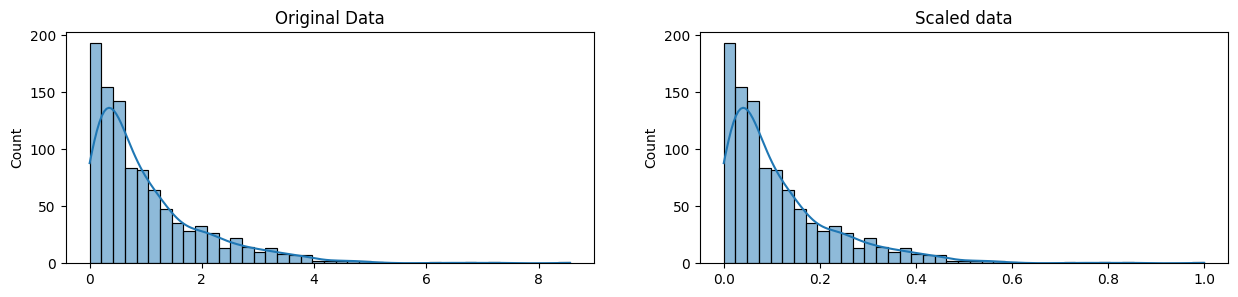

In [ ]:
# generate 1000 data points randomly drawn from an exponential distribution
original_data = np.random.exponential(size=1000)

# mix-max scale the data between 0 and 1
scaled_data = minmax_scaling(original_data, columns=[0]) # en columns se puede poner un valor de columna en cadena de caracteres es decir por ejemplo 'goal'.

# plot both together to compare
fig, ax = plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(scaled_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title("Scaled data")
plt.show()

### **03.2.4. Normalizacion**
El punto de la normalizacion es cambiar las observaciones que se tiene sobre los datos para que puedan ser descritos como una distribucion normal.

> *¿Que es una distribucion normal?*
>
>También conocida como «curva de campana», se trata de una distribución estadística específica en la que hay aproximadamente el mismo número de observaciones por encima y por debajo de la media, la media y la mediana son iguales, y hay más observaciones cercanas a la media. La distribución normal también se conoce como distribución gaussiana.

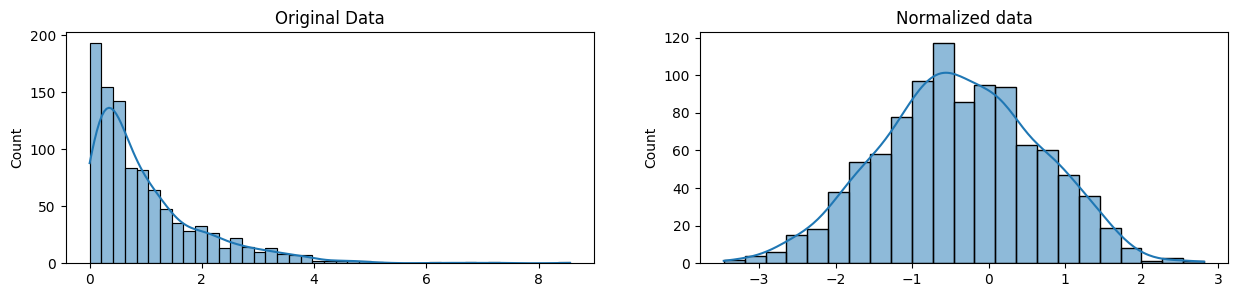

In [ ]:
# normalize the exponential data with boxcox
normalized_data = stats.boxcox(original_data)

# plot both together to compare
fig, ax=plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(normalized_data[0], ax=ax[1], kde=True, legend=False)
ax[1].set_title("Normalized data")
plt.show()


## **03.3. Analisis de fechas**

### **03.3.1. Preparacion del entorno**

In [ ]:
# modules we'll use
import pandas as pd
import numpy as np
import seaborn as sns
import datetime

# read in our data
landslides = pd.read_csv("./archivosDeDatos/catalog.csv")

# set seed for reproducibility
np.random.seed(0)


### **03.3.2. Comprobar el tipo de los datos de la columna de fechas**

In [ ]:
landslides.head()

,id,date,time,continent_code,country_name,country_code,state/province,population,city/town,distance,...,geolocation,hazard_type,landslide_type,landslide_size,trigger,storm_name,injuries,fatalities,source_name,source_link
0,34,3/2/07,Night,NaN,United States,US,Virginia,16000,Cherry Hill,3.40765,...,"(38.600900000000003, -77.268199999999993)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,NBC 4 news,http://www.nbc4.com/news/11186871/detail.html
1,42,3/22/07,NaN,NaN,United States,US,Ohio,17288,New Philadelphia,3.33522,...,"(40.517499999999998, -81.430499999999995)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,Canton Rep.com,http://www.cantonrep.com/index.php?ID=345054&C...
2,56,4/6/07,NaN,NaN,United States,US,Pennsylvania,15930,Wilkinsburg,2.91977,...,"(40.4377, -79.915999999999997)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,The Pittsburgh Channel.com,https://web.archive.org/web/20080423132842/htt...
3,59,4/14/07,NaN,NaN,Canada,CA,Quebec,42786,Châteauguay,2.98682,...,"(45.322600000000001, -73.777100000000004)",Landslide,Riverbank collapse,Small,Rain,NaN,NaN,NaN,Le Soleil,http://www.hebdos.net/lsc/edition162007/articl...
4,61,4/15/07,NaN,NaN,United States,US,Kentucky,6903,Pikeville,5.66542,...,"(37.432499999999997, -82.493099999999998)",Landslide,Landslide,Small,Downpour,NaN,NaN,0.0,Matthew Crawford (KGS),NaN


Estan son las fechas que se quieren manipular y usar, pero como se puede ver son del tipo objeto que es la forma de Pandas de decir que un valor es un conjunto de varios tipos, por lo tanto hay que convertir esta columna de datos a el tipo fechas.

In [ ]:
print(landslides['date'].head())

0     3/2/07
1    3/22/07
2     4/6/07
3    4/14/07
4    4/15/07
Name: date, dtype: object


### **03.3.3. Convertir nuestra columna de fechas a formato fecha**

In [ ]:
# create a new column, date_parsed, with the parsed dates
landslides['date_parsed'] = pd.to_datetime(landslides['date'], format="%m/%d/%y")

In [ ]:
landslides['date_parsed'].head()

,date_parsed
0,2007-03-02
1,2007-03-22
2,2007-04-06
3,2007-04-14
4,2007-04-15


In [ ]:
landslides['date_parsed'] = pd.to_datetime(landslides['Date'], infer_datetime_format=True)

KeyError: 'Date'

### **03.3.4. Seleccionar el dia del mes**

In [ ]:
# get the day of the month from the date_parsed column
day_of_month_landslides = landslides['date_parsed'].dt.day
day_of_month_landslides.head()

,date_parsed
0,2.0
1,22.0
2,6.0
3,14.0
4,15.0


### **03.3.5. Representa gráficamente el día del mes para comprobar el análisis de la fecha**

/tmp/ipykernel_4379/13696829.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(day_of_month_landslides, kde=False, bins=31)


<Axes: xlabel='date_parsed'>

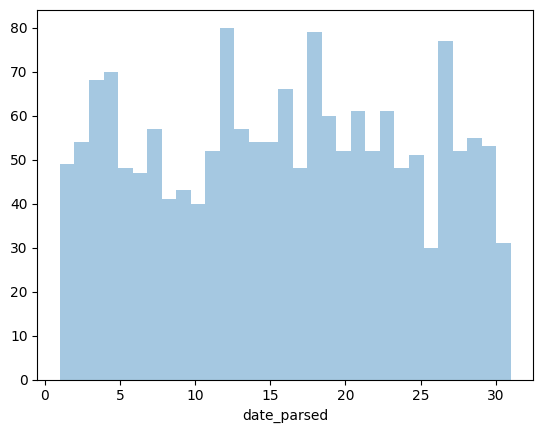

In [ ]:
# remove na's
day_of_month_landslides = day_of_month_landslides.dropna()

# plot the day of the month
sns.distplot(day_of_month_landslides, kde=False, bins=31)

## **03.4. Codificaciones de los caracteres**

### **03.4.1. Preparacion del entorno**

In [ ]:
# modules we'll use
import pandas as pd
import numpy as np

# helpful character encoding module
import charset_normalizer

# set seed for reproducibility
np.random.seed(0)

### **03.4.2. ¿Que son las codificaciones de los caracteres?**

Son reglas que sirven para representar una letra o caracter de cualquier forma en binario para que el ordenador sea capaz de identificarlo y mostrarlo.

In [ ]:
# start with a string
before = "This is the euro symbol: €"

# check to see what datatype it is
type(before)

str

In [ ]:
# encode it to a different encoding, replacing characters that raise errors
after = before.encode("utf-8", errors="replace")

# check the type
type(after)

bytes

In [ ]:
after

b'This is the euro symbol: \xe2\x82\xac'

In [ ]:
# convert it back to utf-8
print(after.decode("utf-8"))

This is the euro symbol: €


In [ ]:
# try to decode our bytes with the ascii encoding
print(after.decode("ascii"))

UnicodeDecodeError: 'ascii' codec can't decode byte 0xe2 in position 25: ordinal not in range(128)

In [ ]:
# start with a string
before = "This is the euro symbol: €"

# encode it to a different encoding, replacing characters that raise errors
after = before.encode("ascii", errors = "replace")

# convert it back to utf-8
print(after.decode("ascii"))

# We've lost the original underlying byte string! It's been
# replaced with the underlying byte string for the unknown character :(

This is the euro symbol: ?


### **03.4.3. Leectura de archivos con problemas de codificacion de caracteres**

In [ ]:
# try to read in a file not in UTF-8
kickstarter_2016 = pd.read_csv("./archivosDeDatos/ks-projects-201612.csv")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x99 in position 7955: invalid start byte

In [ ]:
# look at the first ten thousand bytes to guess the character encoding
with open("./archivosDeDatos/ks-projects-201612.csv", 'rb') as rawdata:
    result = charset_normalizer.detect(rawdata.read(10000))

# check what the character encoding might be
print(result)

{'encoding': 'windows-1250', 'language': 'English', 'confidence': 1.0}


In [ ]:
# read in the file with the encoding detected by charset_normalizer
kickstarter_2016 = pd.read_csv("./archivosDeDatos/ks-projects-201612.csv", encoding='Windows-1252')

# look at the first few lines
kickstarter_2016.head()

/tmp/ipykernel_4379/3118781811.py:2: DtypeWarning: Columns (13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  kickstarter_2016 = pd.read_csv("./archivosDeDatos/ks-projects-201612.csv", encoding='Windows-1252')


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09 11:36:00,1000,2015-08-11 12:12:28,0,failed,0,GB,0,NaN,NaN,NaN,NaN
1,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26 00:20:50,45000,2013-01-12 00:20:50,220,failed,3,US,220,NaN,NaN,NaN,NaN
2,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16 04:24:11,5000,2012-03-17 03:24:11,1,failed,1,US,1,NaN,NaN,NaN,NaN
3,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29 01:00:00,19500,2015-07-04 08:35:03,1283,canceled,14,US,1283,NaN,NaN,NaN,NaN
4,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,2016-04-01 13:38:27,50000,2016-02-26 13:38:27,52375,successful,224,US,52375,NaN,NaN,NaN,NaN


### **03.4.4. Guardado de datos con la codificacion UTF-8**

In [70]:
kickstarter_2016.to_csv("ks-projects-201801-utf8.csv")

## **03.5. Entradas de datos inconsistentes**

### **03.5.1. Preparacion del entorno**

In [74]:
!pip install fuzzywuzzy

# modules we'll use
import pandas as pd
import numpy as np

# helpful modules
import fuzzywuzzy
from fuzzywuzzy import process
import charset_normalizer

# read in all our data
professors = pd.read_csv("./archivosDeDatos/pakistan_intellectual_capital.csv")

# set seed for reproducibility
np.random.seed(0)

### **03.5.2. Pre procesado de texto preliminar**

In [75]:
professors.head()

,Unnamed: 0,S#,Teacher Name,University Currently Teaching,Department,Province University Located,Designation,Terminal Degree,Graduated from,Country,Year,Area of Specialization/Research Interests,Other Information
0,2,3,Dr. Abdul Basit,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,Software Engineering & DBMS,NaN
1,4,5,Dr. Waheed Noor,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,DBMS,NaN
2,5,6,Dr. Junaid Baber,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,"Information processing, Multimedia mining",NaN
3,6,7,Dr. Maheen Bakhtyar,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,"NLP, Information Retrieval, Question Answering...",NaN
4,24,25,Samina Azim,Sardar Bahadur Khan Women's University,Computer Science,Balochistan,Lecturer,BS,Balochistan University of Information Technolo...,Pakistan,2005.0,VLSI Electronics DLD Database,NaN


In [76]:
# get all the unique values in the 'Country' column
countries = professors['Country'].unique()

# sort them alphabetically and then take a closer look
countries.sort()
countries


array([' Germany', ' New Zealand', ' Sweden', ' USA', 'Australia',
       'Austria', 'Canada', 'China', 'Finland', 'France', 'Greece',
       'HongKong', 'Ireland', 'Italy', 'Japan', 'Macau', 'Malaysia',
       'Mauritius', 'Netherland', 'New Zealand', 'Norway', 'Pakistan',
       'Portugal', 'Russian Federation', 'Saudi Arabia', 'Scotland',
       'Singapore', 'South Korea', 'SouthKorea', 'Spain', 'Sweden',
       'Thailand', 'Turkey', 'UK', 'USA', 'USofA', 'Urbana', 'germany'],
      dtype=object)

In [78]:
# convert to lower case
professors['Country'] = professors['Country'].str.lower()
# remove trailing white spaces
professors['Country'] = professors['Country'].str.strip()


### **03.5.3. Usar la libreria fuzzy para indexar los datos incosistentes**

In [79]:
# get all the unique values in the 'Country' column
countries = professors['Country'].unique()

# sort them alphabetically and then take a closer look
countries.sort()
countries


array(['australia', 'austria', 'canada', 'china', 'finland', 'france',
       'germany', 'greece', 'hongkong', 'ireland', 'italy', 'japan',
       'macau', 'malaysia', 'mauritius', 'netherland', 'new zealand',
       'norway', 'pakistan', 'portugal', 'russian federation',
       'saudi arabia', 'scotland', 'singapore', 'south korea',
       'southkorea', 'spain', 'sweden', 'thailand', 'turkey', 'uk',
       'urbana', 'usa', 'usofa'], dtype=object)

Vamos a utilizar el paquete «fuzzywuzzy» para identificar qué cadenas son las más parecidas entre sí. Este conjunto de datos es lo suficientemente pequeño como para que probablemente pudiéramos corregir los errores a mano, pero ese enfoque no se adapta bien a grandes volúmenes. (¿Te apetecería corregir mil errores a mano? ¿Y diez mil? Automatizar las tareas lo antes posible suele ser una buena idea. Además, ¡es divertido!)

>Coincidencia difusa(fuzzy): proceso que consiste en encontrar automáticamente cadenas de texto muy similares a la cadena objetivo. En general, se considera que una cadena está «más cerca» de otra cuanto menos caracteres haya que cambiar para transformar una cadena en otra. Así, «apple» y «snapple» están separadas por dos cambios (añadir «s» y «n»), mientras que «in» y «on» lo están por un solo cambio (sustituir «i» por «o»). No siempre podrás confiar al 100 % en la coincidencia aproximada, pero normalmente te ahorrará al menos un poco de tiempo.

Fuzzywuzzy devuelve una proporción dada una pareja de cadenas. Cuanto más se acerque la proporción a 100, menor será la distancia de edición entre las dos cadenas. En este caso, vamos a obtener las diez cadenas de nuestra lista de ciudades que tengan la distancia más cercana a «south korea».

In [80]:
# get the top 10 closest matches to "south korea"
matches = fuzzywuzzy.process.extract("south korea", countries, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

# take a look at them
matches

[('south korea', 100),
 ('southkorea', 48),
 ('saudi arabia', 43),
 ('norway', 35),
 ('ireland', 33),
 ('portugal', 32),
 ('singapore', 30),
 ('netherland', 29),
 ('macau', 25),
 ('usofa', 25)]